In [85]:
#! pip install pctk

In [86]:
from pctk import multicellds
import pandas as pd
import matplotlib.pyplot as plt
from plot_df_journal_style_ext import plot_panels

In [87]:
output_path = "../../../../output/"

In [88]:
# Creating a MCDS reader
reader = multicellds.MultiCellDS(output_folder=output_path)

In [89]:
data = []
for t, a in reader.microenvironment_as_matrix_iterator():
    data.append((t/60, (a[5].sum() / len(a[5])), (a[6].sum() / len(a[6])), (a[4].sum() / len(a[4])) ))

In [90]:
reader.microenvironment_columns

[('oxygen', 'dimensionless', '0'),
 ('glucose', 'dimensionless', '1'),
 ('acetate', 'dimensionless', '2'),
 ('CO2', 'dimensionless', '3')]

<Axes: xlabel='time'>

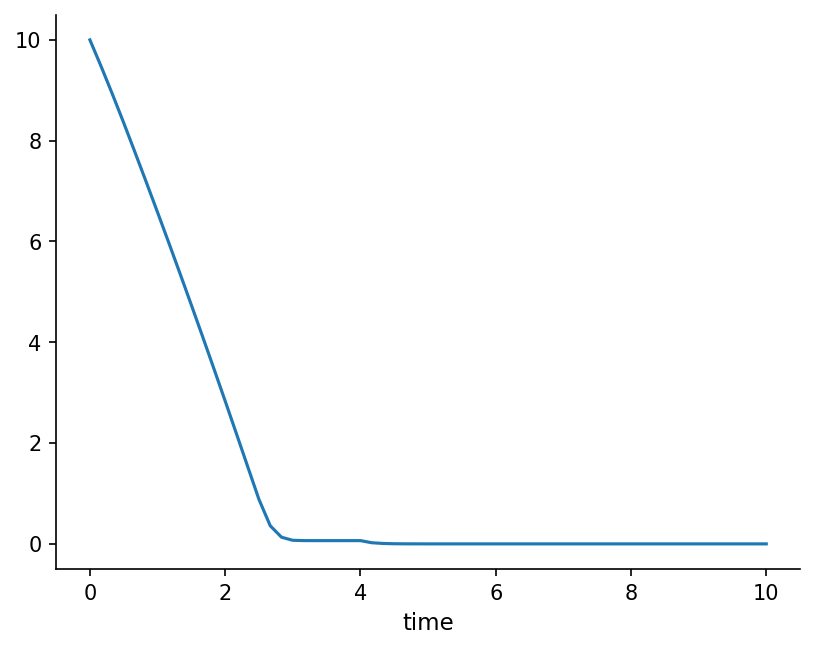

In [91]:
d_substrates = pd.DataFrame(data=data, columns=["time", "glucose", "acetate", "oxygen"]).set_index("time")
d_substrates["glucose"].plot()

In [92]:
reader.cell_columns

['ID',
 'x_position',
 'y_position',
 'z_position',
 'total_volume',
 'cell_type',
 'cycle_model',
 'current_phase',
 'elapsed_time_in_phase',
 'nuclear_volume',
 'cytoplasmic_volume',
 'fluid_fraction',
 'calcified_fraction',
 'x_orientation',
 'y_orientation',
 'z_orientation',
 'polarity',
 'x_velocity',
 'y_velocity',
 'z_velocity',
 'pressure',
 'number_of_nuclei',
 'total_attack_time',
 'contact_with_basement_membrane',
 'current_cycle_phase_exit_rate',
 'elapsed_time_in_phase',
 'dead',
 'current_death_model',
 'x_death_rates',
 'y_death_rates',
 'cytoplasmic_biomass_change_rate',
 'nuclear_biomass_change_rate',
 'fluid_change_rate',
 'calcification_rate',
 'target_solid_cytoplasmic',
 'target_solid_nuclear',
 'target_fluid_fraction',
 'radius',
 'nuclear_radius',
 'surface_area',
 'cell_cell_adhesion_strength',
 'cell_BM_adhesion_strength',
 'cell_cell_repulsion_strength',
 'cell_BM_repulsion_strength',
 'cell_adhesion_affinities',
 'relative_maximum_adhesion_distance',
 'maxim

In [93]:
data = []
for t, a in reader.cells_as_matrix_iterator():
    total_volume = a[:,4].sum() # um3
    scaled_volume = total_volume / 10**12 # mL
    density = 1.04 # g/ml
    solid_fraction = 0.25
    biomass = scaled_volume * density * solid_fraction
    #print("total volume is ", total_volume)
    data.append((t/60, a[:,-2].mean(), a.shape[0], biomass))

<Axes: xlabel='time'>

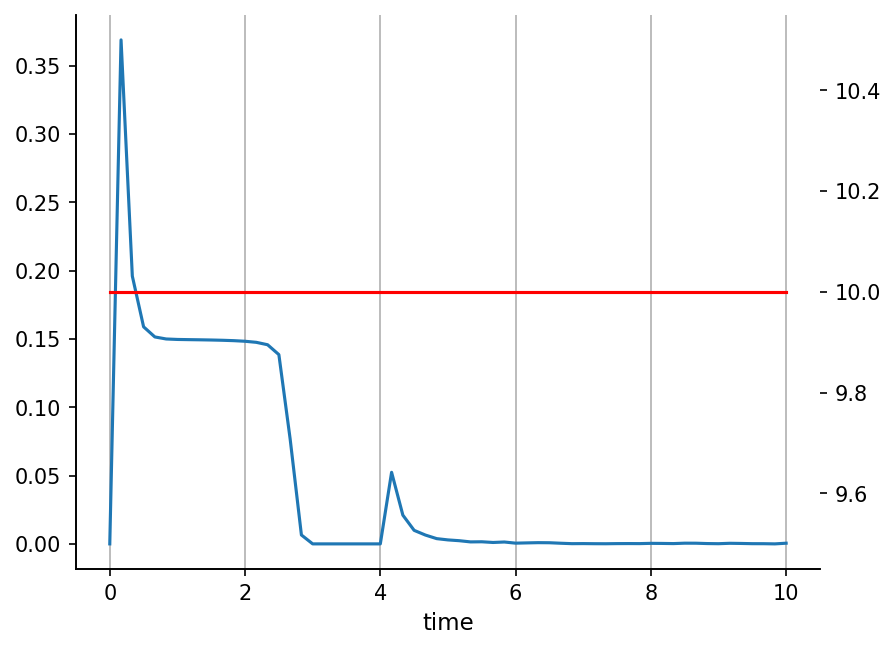

In [94]:
d_cells = pd.DataFrame(data=data, columns=["time", "growth_rate", "n_cells", "total_biomass"]).set_index("time")
ax = d_cells["growth_rate"].plot()
ax.grid(axis="x")
ax = ax.twinx()
d_cells["n_cells"].plot(ax=ax, c="red")

/home/mruscone/Desktop/github/PhysiCelldFBA/sample_projects_intracellular/fba/ecoli_acetic_switch/scripts/plot_df_journal_style_ext.py:203: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.35, bottom=0.20)


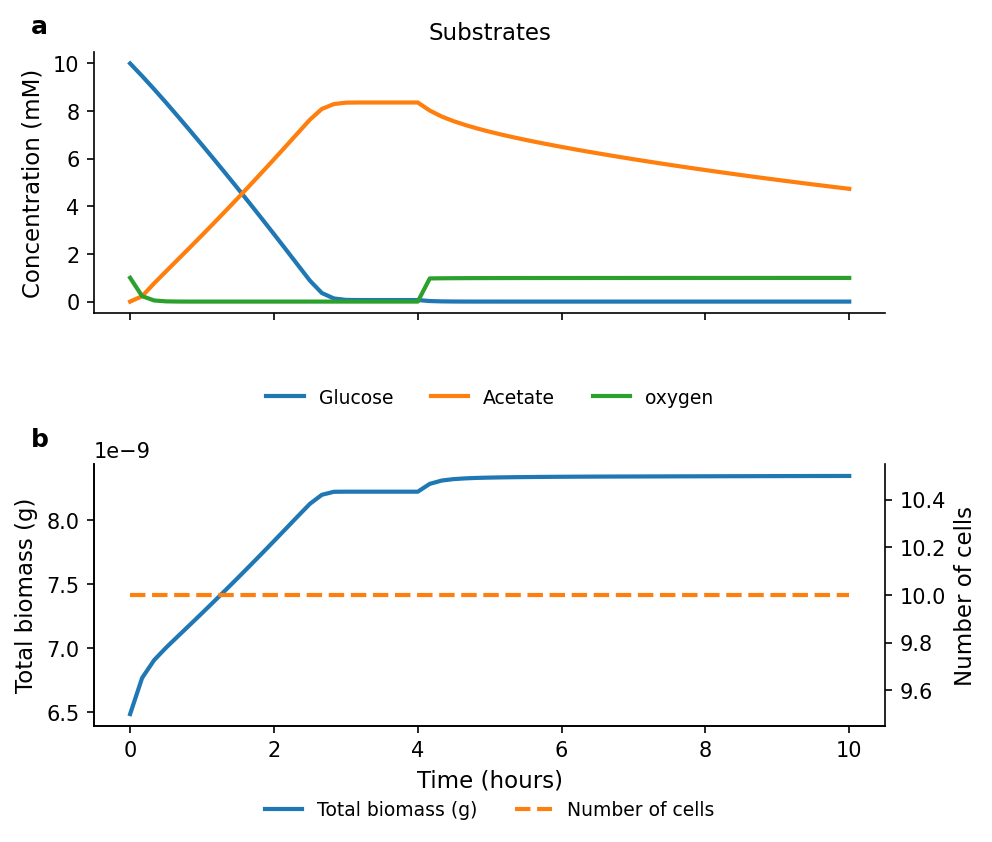

In [95]:
fig, axes = plot_panels(
    d_substrates=d_substrates,
    d_cells=d_cells,
    substrates_cols=["glucose", "acetate", "oxygen"],
    substrates_twin_if_two=True,
    ylabel_top_left="Concentration (mM)",
    ylabel_top_right="Concentration (mM)",
    cell_left_col="total_biomass",
    cell_right_col="n_cells",
    ylabel_bottom_left="Total biomass (g)",
    ylabel_bottom_right="Number of cells",
    labels={
        "glucose": "Glucose",
        "acetate": "Acetate",
        "total_biomass": "Total biomass (g)",
        "n_cells": "Number of cells",
    },
    save_prefix="figure_v2",
    right_axis_sci=False,
    substrates_color_mode="distinct"
)